# Import libraries

In [57]:
from datetime import datetime
import numpy as np
import pandas as pd
from dateutil.parser import parse
import networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt
import json

# Layer 1: Dedup

In [58]:
# Lấy fingerprint của mỗi alert 

def fingerprint(alert: dict) -> str:
    return f"{alert['service']}|{alert['metric']}|{alert['severity']}"


In [59]:
from collections import defaultdict
from datetime import datetime

class Deduper:
    def __init__(self):
        self.store: dict[str, dict] = {}  # fingerprint → cluster info
    
    def push(self, alert: dict) -> str:
        """
        Add alert vào store. Return cluster_id (fingerprint đóng vai trò cluster_id ở layer này).
        """
        fp = fingerprint(alert)
        ts = datetime.fromisoformat(alert['ts'].replace('Z', '+00:00'))
        
        if fp not in self.store:
            self.store[fp] = {
                'cluster_id': fp,
                'count': 1,
                'first_seen': ts,
                'last_seen': ts,
                'alerts': [alert['id']],
                'max_value': alert['value'],
            }
        else:
            c = self.store[fp]
            c['count'] += 1
            c['last_seen'] = ts
            c['alerts'].append(alert['id'])
            c['max_value'] = max(c['max_value'], alert['value'])
        
        return fp
    
    def clusters(self) -> list[dict]:
        return list(self.store.values())


# Layer 2 - Time-Window (gom alert gần nhau về thời gian)

In [60]:
def session_groups(alerts: list[dict], gap_sec: int = 120) -> list[list[dict]]:
    """
    Mỗi group là 1 'session' alert. Session kết thúc khi không alert nào trong gap_sec giây.
    
    Vì sao session tốt hơn tumbling cho incident:
    - Incident burst: 30 alert trong 90 giây → 1 session tự nhiên
    - Tumbling 5min: nếu incident span 4 phút 30 - 5 phút 30 → bị cắt thành 2 window
    - Session tự adapt kích thước theo burst pattern
    """
    if not alerts:
        return []
    
    sorted_alerts = sorted(alerts, key=lambda a: a['ts'])
    groups = [[sorted_alerts[0]]]
    
    for alert in sorted_alerts[1:]:
        ts = datetime.fromisoformat(alert['ts'].replace('Z', '+00:00'))
        last_ts = datetime.fromisoformat(groups[-1][-1]['ts'].replace('Z', '+00:00'))
        
        if (ts - last_ts).total_seconds() <= gap_sec:
            groups[-1].append(alert)
        else:
            groups.append([alert])
    
    return groups


# Layer 3 - Topology gom alert theo cấu trúc service

In [61]:
import networkx as nx
import json

def build_graph(services_json_path: str) -> nx.DiGraph:

    g = nx.DiGraph()
    data = json.loads(open(services_json_path).read())
    
    # Add service nodes
    for svc in data['services']:
        g.add_node(svc['name'], **{k: v for k, v in svc.items() if k != 'name'})
    
    # Add store nodes
    for store in data['stores']:
        g.add_node(store['name'], **{k: v for k, v in store.items() if k != 'name'})
    
    # Add edges
    for edge in data['edges']:
        g.add_edge(edge['from'], edge['to'], type=edge['type'])
    
    return g


In [62]:
def topology_group(alerts: list[dict], graph: nx.DiGraph, max_hop: int = 1) -> list[list[dict]]:
    """
    Group alerts nếu service của chúng cách nhau ≤ max_hop trên service graph.
    
    Lưu ý: dùng undirected version của graph cho khoảng cách — vì cascade
    có thể đi cả 2 chiều (upstream effect, downstream propagation tùy case).
    """
    if not alerts:
        return []
    
    undirected = graph.to_undirected()
    
    # Build mapping service → alerts ở service đó
    by_service = defaultdict(list)
    for a in alerts:
        by_service[a['service']].append(a)
    
    services_with_alerts = list(by_service.keys())
    
    # Union-Find
    parent = {s: s for s in services_with_alerts}
    
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    
    def union(x, y):
        parent[find(x)] = find(y)
    
    # Two services cùng group nếu khoảng cách ≤ max_hop trên graph
    for i, s1 in enumerate(services_with_alerts):
        for s2 in services_with_alerts[i+1:]:
            try:
                dist = nx.shortest_path_length(undirected, s1, s2)
                if dist <= max_hop:
                    union(s1, s2)
            except nx.NetworkXNoPath:
                continue  # 2 service không connected → không group
    
    # Collect groups
    groups_dict = defaultdict(list)
    for s in services_with_alerts:
        groups_dict[find(s)].extend(by_service[s])
    
    return list(groups_dict.values())


In [63]:
def correlate(alerts: list[dict], graph: nx.DiGraph, gap_sec: int = 49, max_hop: int = 1):
    """
    Pipeline:
      1. Sort alert by timestamp
      2. Cho mỗi session (time-window), apply topology grouping
      3. Output clusters
    """
    sessions = session_groups(alerts, gap_sec=gap_sec)
    
    all_clusters = []
    for session_idx, session_alerts in enumerate(sessions):
        # Trong mỗi session, topology-group
        topo_groups = topology_group(session_alerts, graph, max_hop=max_hop)
        for group_idx, group in enumerate(topo_groups):
            all_clusters.append({
                'cluster_id': f'c-{session_idx:03d}-{group_idx:03d}',
                'alert_count': len(group),
                'services': sorted(set(a['service'] for a in group)),
                # 'alert_ids': [a['id'] for a in group],
                'time_range': [min(a['ts'] for a in group), max(a['ts'] for a in group)],
                'max_severity': max(a['severity'] for a in group),
                "fingerprints": sorted(set(fingerprint(a) for a in group))
            })
    
    return all_clusters


# Tính khoảng cách thời gian và 95 percentile => tính gap_sec

In [64]:
import json
import networkx as nx
import json

# Main
# Build nodes and paths for servcies
SERVICE_JSON_PATH = "dataset/services.json"
ALERT_JSONL_PATH = "dataset/alerts_sample.jsonl"
CLUSTER_SUMMARY_PATH = "results/cluster_summary.json"

graph = build_graph(SERVICE_JSON_PATH)


with open(ALERT_JSONL_PATH, 'r', encoding='utf-8') as file:
    data_list = [json.loads(line) for line in file if line.strip()]

print(data_list)

[{'id': 'a-0001', 'ts': '2026-06-12T09:42:01Z', 'service': 'payment-svc', 'metric': 'db_connection_pool_used_ratio', 'severity': 'warn', 'value': 0.85, 'threshold': 0.8, 'labels': {'env': 'prod', 'region': 'ap-southeast-1'}}, {'id': 'a-0002', 'ts': '2026-06-12T09:42:18Z', 'service': 'payment-svc', 'metric': 'db_connection_pool_used_ratio', 'severity': 'crit', 'value': 0.99, 'threshold': 0.95, 'labels': {'env': 'prod', 'region': 'ap-southeast-1'}}, {'id': 'a-0003', 'ts': '2026-06-12T09:42:22Z', 'service': 'payment-svc', 'metric': 'latency_p99_ms', 'severity': 'crit', 'value': 1840, 'threshold': 800, 'labels': {'env': 'prod', 'region': 'ap-southeast-1'}}, {'id': 'a-0004', 'ts': '2026-06-12T09:42:30Z', 'service': 'payment-svc', 'metric': 'error_rate', 'severity': 'warn', 'value': 0.04, 'threshold': 0.02, 'labels': {'env': 'prod', 'region': 'ap-southeast-1'}}, {'id': 'a-0005', 'ts': '2026-06-12T09:42:45Z', 'service': 'checkout-svc', 'metric': 'latency_p99_ms', 'severity': 'warn', 'value': 

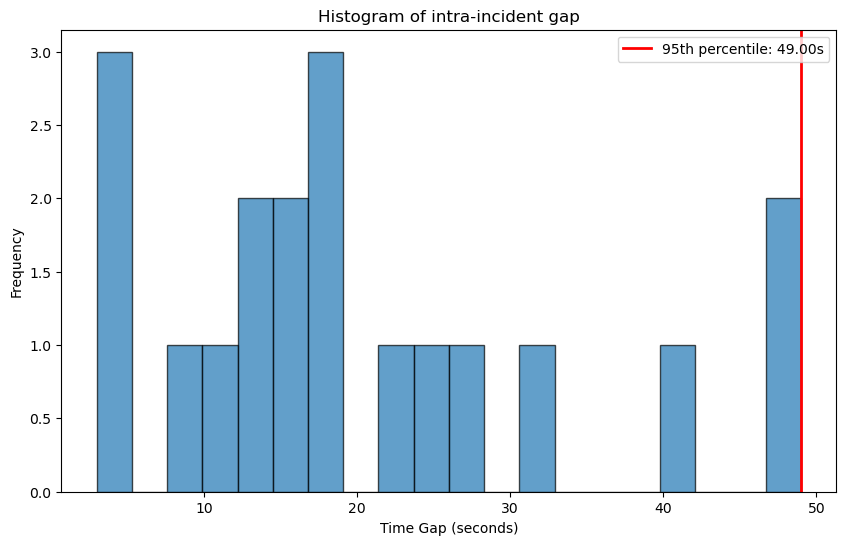

gap_sec = 49.00


In [65]:

def parse_ts(ts: str):
    return datetime.fromisoformat(ts.replace("Z", "+00:00"))

def calculate_optimal_gap(alerts):
    timestamps = sorted([parse_ts(a['ts']) for a in alerts])
    
    gap_sec = [(timestamps[i+1] - timestamps[i]).total_seconds() for i in range(len(timestamps)-1)]
    p95 = np.percentile(gap_sec, 95)

    
    plt.figure(figsize=(10, 6))
    plt.hist(gap_sec, bins=20, edgecolor='black', alpha=0.7)
    plt.axvline(p95, color='red', linewidth=2, label=f'95th percentile: {p95:.2f}s')
    
    plt.title('Histogram of intra-incident gap')
    plt.xlabel('Time Gap (seconds)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()
    
    return p95

optimal_gap_sec = calculate_optimal_gap(data_list)
print(f"gap_sec = {optimal_gap_sec:.2f}")

In [66]:
all_clusters = correlate(data_list, graph, gap_sec=49, max_hop=1)

input_count = len(data_list)
output_count = len(all_clusters)
reduction_ratio = 0
if input_count > 0:
    reduction_ratio = round(1 - (output_count / input_count), 2)


cluster_summary = {
    "input_alerts": input_count,
    "output_clusters": output_count,
    "reduction_ratio": reduction_ratio,
    "clusters": all_clusters
}

print(cluster_summary)

with open(CLUSTER_SUMMARY_PATH, 'w', encoding='utf-8') as file:
    json.dump(cluster_summary, file, ensure_ascii=False, indent=4)

{'input_alerts': 20, 'output_clusters': 2, 'reduction_ratio': 0.9, 'clusters': [{'cluster_id': 'c-000-000', 'alert_count': 19, 'services': ['cart-svc', 'checkout-svc', 'edge-lb', 'notification-svc', 'payment-svc', 'search-svc'], 'time_range': ['2026-06-12T09:42:01Z', '2026-06-12T09:48:30Z'], 'max_severity': 'warn', 'fingerprints': ['cart-svc|latency_p99_ms|warn', 'checkout-svc|downstream_payment_error_rate|crit', 'checkout-svc|latency_p99_ms|crit', 'checkout-svc|latency_p99_ms|warn', 'checkout-svc|request_drop_rate|crit', 'edge-lb|p99_latency_ms|crit', 'edge-lb|upstream_5xx_rate|crit', 'edge-lb|upstream_5xx_rate|warn', 'notification-svc|queue_depth|crit', 'notification-svc|queue_lag_ms|warn', 'payment-svc|db_connection_pool_used_ratio|crit', 'payment-svc|db_connection_pool_used_ratio|warn', 'payment-svc|error_rate|crit', 'payment-svc|error_rate|warn', 'payment-svc|latency_p99_ms|crit', 'search-svc|catalog_db_query_time_ms|warn']}, {'cluster_id': 'c-000-001', 'alert_count': 1, 'services